ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
/home/users/kastanie/nb_envs/name-of-environment/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_identify: Open of /apps/jasmin/jaspy/miniforge_

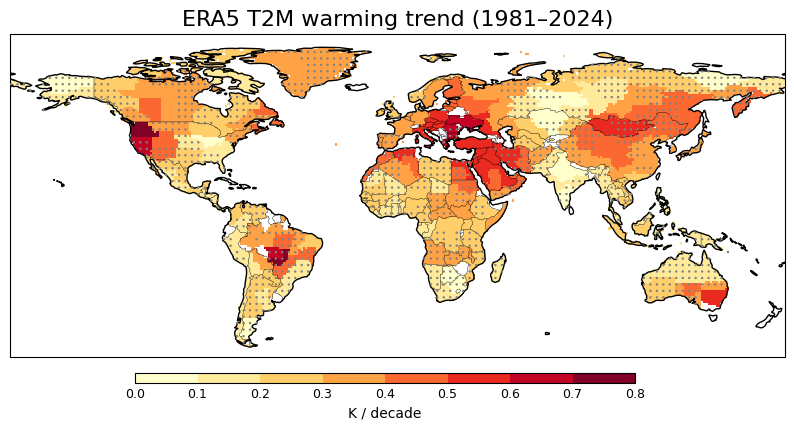

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import matplotlib.colors as mcolors

# =========================================================
# 1. Load datasets
# =========================================================
ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# =========================================================
# 2. Select period
# =========================================================
ds_sel = ds.sel(year=slice(1981, 2024))
years = ds_sel.year.values
n_regions = ds_sel.region_id.size

# =========================================================
# 3. Compute trends per region
# =========================================================
trend = np.full((n_regions,), np.nan)

for i in range(n_regions):
    y = ds_sel['t2m_hottest'][:, i].values
    if np.isnan(y).all():
        continue

    slope, _, _, _, _ = linregress(years, y)
    trend[i] = slope * 10.0  # K/decade

# =========================================================
# 4. Map regional trends to lat-lon grid
# =========================================================
region_ids = region_mask_ds['region_id'].values
lat = region_mask_ds['latitude'].values
lon = region_mask_ds['longitude'].values

trend_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue

    rid = int(rid)
    if rid < n_regions:
        trend_map[region_ids == rid] = trend[rid]

# =========================================================
# 5. Apply fidelity mask (modified: use scatter later)
# =========================================================
fidelity_mask = (fidelity_ds['fidelity_score'] == 3).values

GREY_VAL = -9999

masked_trend = trend_map.copy()

# ---------------------------------------------------------
# 不再用灰色填充，而是后面用 scatter 打点
# ---------------------------------------------------------

levels = np.arange(0, 0.801, 0.1)
MIN_LEVEL = levels[0]

masked_trend[(masked_trend > GREY_VAL) & (masked_trend < MIN_LEVEL)] = MIN_LEVEL

# === 为 scatter 构造稀疏掩膜（每隔2格） ===
SCATTER_STEP = 3
lon2d, lat2d = np.meshgrid(lon, lat)

low_fidelity_mask = (~fidelity_mask) & (~np.isnan(region_ids))
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask & sparse_mask

# =========================================================
# 6. Colormap and normalization
# =========================================================
colors = plt.get_cmap("YlOrRd")(np.linspace(0, 1, len(levels) - 1))
cmap = mcolors.ListedColormap(['silver'] + list(colors))

bounds = [GREY_VAL - 0.5] + list(levels)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 7. Plot
# =========================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    lon,
    lat,
    masked_trend,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# === 用 scatter 标记 fidelity 不好的区域 ===
ax.scatter(
    lon2d[low_fidelity_sparse],
    lat2d[low_fidelity_sparse],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.set_title("ERA5 T2M warming trend (1981–2024)", fontsize=16)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([-180, 180, -60, 90], ccrs.PlateCarree())

# =========================================================
# 8. Colorbar (no grey shown)
# =========================================================
cmap_cbar = mcolors.ListedColormap(colors)
norm_cbar = mcolors.BoundaryNorm(levels, cmap_cbar.N)

sm = plt.cm.ScalarMappable(cmap=cmap_cbar, norm=norm_cbar)
sm.set_array([])

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.02])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation='horizontal',
    ticks=levels
)

cbar.ax.tick_params(labelsize=9, length=0)
cbar.set_label("K / decade", fontsize=10)

# =========================================================
# 9. Save
# =========================================================
plt.savefig(
    "ERA5_t2m_trend_hottest_month_1981_2024_masked.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


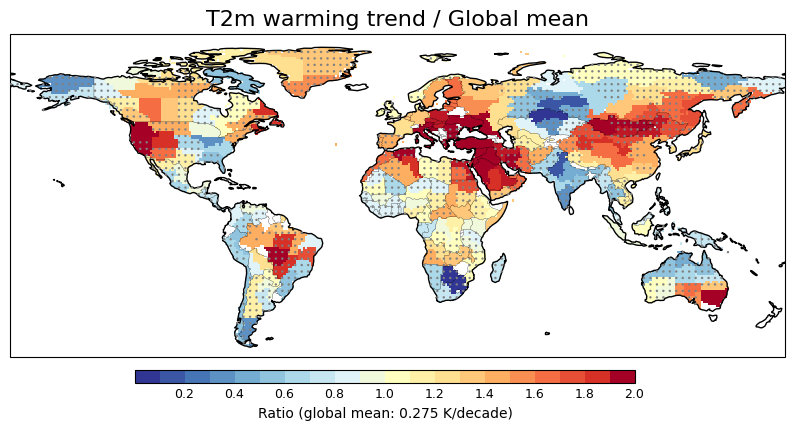

1981–2024 全球平均增暖速率: 0.2754 K/decade
最小显示比值: 0.003021


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

# --- 1. Load data ---
ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# --- 2. Select time ---
ds_sel = ds.sel(year=slice(1981, 2024))
years = ds_sel.year.values
n_regions = ds_sel.region_id.size

# --- 3. Compute trends ---
trend = np.full(n_regions, np.nan)

for i in range(n_regions):
    y = ds_sel.t2m_hottest[:, i].values
    if np.isnan(y).all():
        continue

    x = years - years[0]
    slope, _, _, _, _ = linregress(x, y)
    trend[i] = slope * 10   # K / decade

# --- 4. Map back to grid ---
region_ids = region_mask_ds["region_id"].values
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

trend_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < n_regions:
        trend_map[region_ids == rid] = trend[rid]

# --- 5. Relative map ---
global_mean_trend = np.nanmean(trend)
relative_map = trend_map / global_mean_trend

# --- 6. Fidelity masking (modified: use scatter later) ---
fidelity_mask = (fidelity_ds["fidelity_score"] == 3).values

GREY_VAL = -9999
masked_map = relative_map.copy()

# 不再用灰色填充，只保留原数据，后面用 scatter 标记
# masked_map[~fidelity_mask & ~np.isnan(region_ids)] = GREY_VAL

# === 构造 scatter 稀疏 mask（每隔2格） ===
SCATTER_STEP = 3
lon2d, lat2d = np.meshgrid(lon, lat)

low_fidelity_mask = (~fidelity_mask) & (~np.isnan(region_ids))
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
low_fidelity_sparse = low_fidelity_mask & sparse_mask

# --- 7. Robust bin construction ---
max_ratio = 2.0
step = 0.1

# Find smallest positive valid value
valid_vals = masked_map[(masked_map > 0) & np.isfinite(masked_map)]
vmin = max(valid_vals.min(), 1e-6)

# Bins
bounds = (
    [GREY_VAL - 1, GREY_VAL + 1] +
    list(np.arange(vmin, max_ratio + step, step))
)

# Colormap
colors = (
    ["silver"] +
    list(
        plt.get_cmap("RdYlBu_r", len(bounds) - 2)(
            np.linspace(0, 1, len(bounds) - 2)
        )
    )
)

cmap = mcolors.ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# --- 8. Plot ---
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.pcolormesh(
    lon,
    lat,
    masked_map,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# === fidelity 不好的区域用 scatter 打点 ===
ax.scatter(
    lon2d[low_fidelity_sparse],
    lat2d[low_fidelity_sparse],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.set_title("T2m warming trend / Global mean", fontsize=16)

# --- 9. Colorbar (no grey) ---
cmap_cbar = plt.get_cmap("RdYlBu_r", len(bounds) - 2)
norm_cbar = BoundaryNorm(bounds[2:], cmap_cbar.N)

sm = plt.cm.ScalarMappable(cmap=cmap_cbar, norm=norm_cbar)
sm.set_array([])

tick_step = 0.2
ticks = np.arange(0, max_ratio + 0.001, tick_step)

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.025])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation="horizontal",
    ticks=ticks
)

cbar.set_ticklabels([f"{v:.1f}" for v in ticks])

cbar.set_label(
    f"Ratio (global mean: {global_mean_trend:.3f} K/decade)",
    fontsize=10
)

cbar.ax.tick_params(labelsize=9, length=0)
cbar.minorticks_off()

# --- 10. Save ---
plt.savefig(
    "ERA5_trend_relative_to_global_mean_masked.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- 11. Output ---
print(f"1981–2024 全球平均增暖速率: {global_mean_trend:.4f} K/decade")
print(f"最小显示比值: {vmin:.6f}")


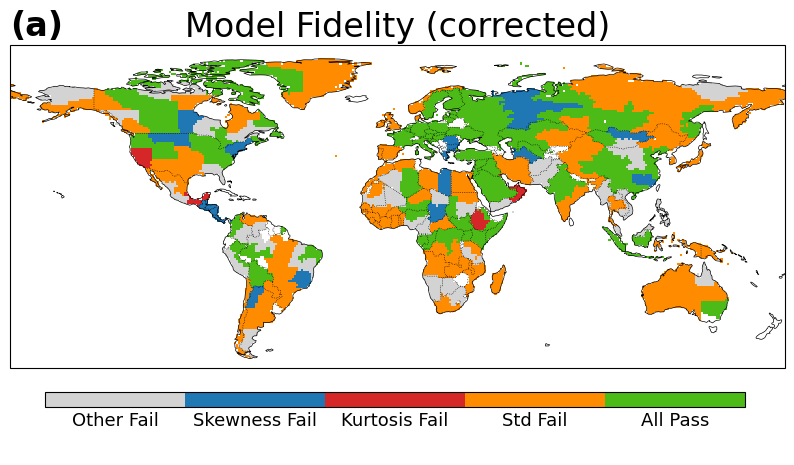

In [9]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from scipy.signal import detrend

def load_and_test_statistics(era5_file, proxy_file, region_grid_ds):
    era5_dataset = xr.open_dataset(era5_file)
    proxy_dataset = xr.open_dataset(proxy_file)
    regions = era5_dataset.region_id.values

    era5_stds = np.zeros(len(regions))
    era5_skews = np.zeros(len(regions))
    era5_kurts = np.zeros(len(regions))

    proxy_stds = proxy_dataset.stds.values
    proxy_skews = proxy_dataset.skews.values
    proxy_kurts = proxy_dataset.kurts.values

    # 分类码：
    # 0 = 多重失败或其他
    # 1 = skewness fail
    # 2 = kurtosis fail
    # 3 = std fail
    # 4 = all pass
    category = np.zeros(len(regions))

    for i, region in enumerate(regions):
        era5_data = era5_dataset.sel(region_id=region, year=slice(1981, 2024)).t2m_hottest
        era5_data_detrended = detrend(era5_data, axis=0)

        era5_stds[i] = era5_data_detrended.std()
        era5_skews[i] = stats.skew(era5_data_detrended)
        era5_kurts[i] = stats.kurtosis(era5_data_detrended)

        std_5th, std_95th = np.percentile(proxy_stds[:, i], [5, 95])
        skew_5th, skew_95th = np.percentile(proxy_skews[:, i], [5, 95])
        kurt_5th, kurt_95th = np.percentile(proxy_kurts[:, i], [5, 95])

        std_pass = std_5th <= era5_stds[i] <= std_95th
        skew_pass = skew_5th <= era5_skews[i] <= skew_95th
        kurt_pass = kurt_5th <= era5_kurts[i] <= kurt_95th

        # 分类逻辑
        if std_pass and skew_pass and kurt_pass:
            category[i] = 4  # 全部通过
        elif not skew_pass and std_pass and kurt_pass:
            category[i] = 1  # 仅 skewness 失败
        elif not kurt_pass and std_pass and skew_pass:
            category[i] = 2  # 仅 kurtosis 失败
        elif not std_pass and skew_pass and kurt_pass:
            category[i] = 3  # 仅 std 失败
        else:
            category[i] = 0  # 多重失败或其他

    region_grid = region_grid_ds.region_id
    category_grid = xr.full_like(region_grid, np.nan, dtype=float)

    for i, rid in enumerate(regions):
        category_grid = category_grid.where(region_grid != rid, category[i])

    return category_grid

# === 执行检验并绘图 ===
region_grid_ds = xr.open_dataset("/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc")

grid_category = load_and_test_statistics(
    "Berkeley_hottest_month_by_region_revised_by_ERA5.nc",
    "IFS_proxy_statistics_hottest_regional_1981_2024_land_bias_corrected.nc",
    region_grid_ds
)

# 颜色映射
cmap = mcolors.ListedColormap([
    "#D3D3D3",  # 0: 多重失败或其他
    "#1f77b4",  # 1: skewness fail (蓝)
    "#d62728",  # 2: kurtosis fail (红)
    "#ff8c00",  # 3: std fail (橙)
    "#4cbb17"   # 4: all pass (绿)
])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

# 绘图
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_title("Model Fidelity (corrected)", fontsize=24)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
ax.text(
    0.0,
    1.03,
    "(a)",
    transform=ax.transAxes,
    fontsize=24,
    ha="left",
    fontweight = 'bold'
)
im = ax.pcolormesh(region_grid_ds.longitude, region_grid_ds.latitude, grid_category,
                   shading="auto", cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Colorbar
cbar_ax = fig.add_axes([0.16,0.095,0.7,0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                    ticks=[0, 1, 2, 3, 4])
cbar.ax.set_xticklabels([
    "Other Fail", "Skewness Fail", "Kurtosis Fail", "Std Fail", "All Pass"
])
cbar.ax.tick_params(which='both', length=0, labelsize = 13)
cbar.set_label(" ", fontsize=16)
plt.savefig("IFS_Statistics_Fidelity_DetailMap.pdf", dpi=300, bbox_inches="tight")
plt.show()


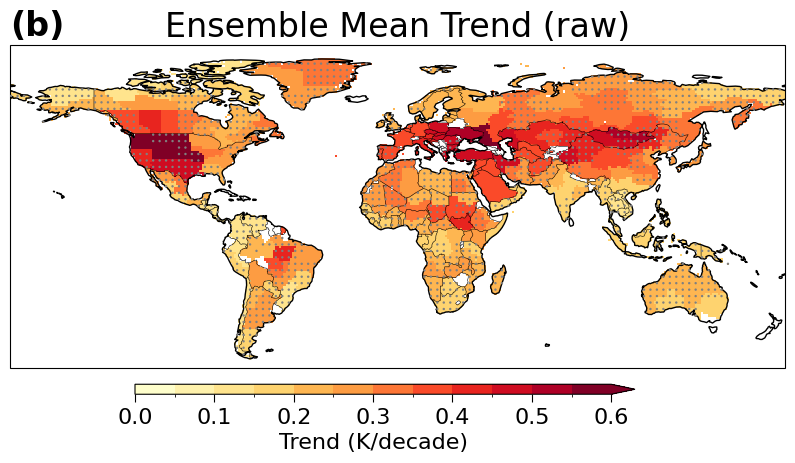

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
from matplotlib.colors import BoundaryNorm
import matplotlib as mpl

# === 1. Load data ===
era5_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
ens_ds  = xr.open_dataset("IFS_t2m_hottest_month.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# === 2. Preprocess ===
era5_sel = era5_ds.sel(year=slice(1981, 2024))
era5_years = era5_sel.year.values

ens_t2m = ens_ds["t2m_hottest_month"].transpose("year", "region_id", "number")
ens_years = ens_ds.year.values

# === 3. Bias correction based on ERA5 in time segments ===
segments = [(1981,1990), (1991,2000), (2001,2010), (2011,2020), (2021,2024)]

ens_t2m_corrected = ens_t2m.copy()

for start, end in segments:
    era5_seg_mean = era5_sel.sel(year=slice(start,end)).t2m_hottest.mean(dim="year")
    ens_seg_mean = ens_t2m_corrected.sel(year=slice(start,end)).mean(dim="year")
    delta = era5_seg_mean - ens_seg_mean
    ens_t2m_corrected.loc[dict(year=slice(start,end))] += delta

# === 4. Compute ensemble mean after bias correction ===
#ens_mean = ens_t2m_corrected.mean(dim="number")
ens_mean = ens_t2m.mean(dim="number")
# === 5. Compute trends (per region) ===
def compute_trend(y_array, x_years):
    slopes = np.full(y_array.shape[1], np.nan)
    x = x_years - x_years[0]
    for i in range(y_array.shape[1]):
        y = y_array[:, i]
        if np.isnan(y).all():
            continue
        slope, *_ = linregress(x, y)
        slopes[i] = slope * 10  # per decade
    return slopes

ens_trend = compute_trend(ens_mean.values, ens_years)

# === 6. Region → grid mapping ===
region_ids = region_mask_ds["region_id"].values
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

trend_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < len(ens_trend):
        trend_map[region_ids == rid] = ens_trend[rid]

# === 7. Fidelity (scatter mask) ===
fidelity_grid = fidelity_ds["fidelity_score"].values
n_regions = len(ens_trend)

region_pass = np.zeros(n_regions, dtype=bool)
for rid in range(n_regions):
    mask = region_ids == rid
    if not np.any(mask):
        continue
    pass_fraction = np.nanmean(fidelity_grid[mask] == 3)
    region_pass[rid] = pass_fraction > 0.5

low_fidelity_mask = np.zeros_like(region_ids, dtype=bool)
for rid in range(n_regions):
    if not region_pass[rid]:
        low_fidelity_mask |= (region_ids == rid)

low_fidelity_mask &= np.isfinite(trend_map)

SCATTER_STEP = 3
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True
scatter_mask = low_fidelity_mask & sparse_mask

lon2d, lat2d = np.meshgrid(lon, lat)

# === 8. Clip minimum trend ===
MIN_TREND = 0.0
trend_map[(trend_map < MIN_TREND)] = MIN_TREND

# === 9. Colormap ===
cmap = plt.get_cmap("YlOrRd")
bounds_real = np.arange(0, 0.601, 0.05)
norm = BoundaryNorm(bounds_real, ncolors=cmap.N, clip=True)

# === 10. Plot ===
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

pcm = ax.pcolormesh(
    lon,
    lat,
    trend_map,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.scatter(
    lon2d[scatter_mask],
    lat2d[scatter_mask],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.text(0.00, 1.03, '(b)', transform=ax.transAxes, fontsize=24, ha="left", fontweight='bold',)
ax.set_title("Ensemble Mean Trend (raw)", fontsize=24)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_extent([-180, 180, -60, 90])

# === 11. Colorbar ===
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
# === 只显示0.1刻度 ===
ticks = np.arange(0, 0.61, 0.1)
cax = fig.add_axes([0.25, 0.12, 0.5, 0.02])
cbar = fig.colorbar(
    sm,
    cax=cax,
    ticks=ticks,
    orientation='horizontal',
    extend="max"
)
cbar.set_label("Trend (K/decade)", fontsize=16)
cbar.ax.tick_params(labelsize=16, length=6)

# === 12. Save ===
plt.savefig(
    "ensemble_mean_trend.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

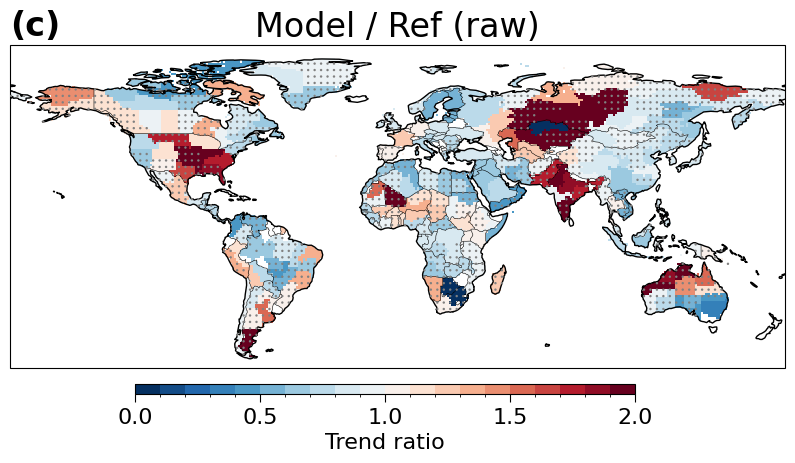

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
from matplotlib.colors import BoundaryNorm
import matplotlib as mpl

# === 1. Load data ===
era5_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
ens_ds  = xr.open_dataset("IFS_t2m_hottest_month.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# === 2. Preprocess ===
era5_sel = era5_ds.sel(year=slice(1981, 2024))
era5_years = era5_sel.year.values

ens_t2m = ens_ds["t2m_hottest_month"].transpose("year", "region_id", "number")
ens_years = ens_ds.year.values

# === ✅ NEW STEP: Bias correction based on ERA5 in time segments ===
segments = [(1981,1990), (1991,2000), (2001,2010), (2011,2020), (2021,2024)]

ens_t2m_corrected = ens_t2m.copy()

for start, end in segments:
    era5_seg_mean = era5_sel.sel(year=slice(start,end)).t2m_hottest.mean(dim="year")
    ens_seg_mean = ens_t2m_corrected.sel(year=slice(start,end)).mean(dim="year")
    # compute difference
    delta = era5_seg_mean - ens_seg_mean
    # broadcast delta to ensemble members
    ens_t2m_corrected.loc[dict(year=slice(start,end))] += delta

# === 3. Compute ensemble mean after bias correction ===
#ens_mean = ens_t2m_corrected.mean(dim="number")
ens_mean = ens_t2m.mean(dim="number")
# === 4. Compute trends ===
def compute_trend(y_array, x_years):

    slopes = np.full(y_array.shape[1], np.nan)
    x = x_years - x_years[0]

    for i in range(y_array.shape[1]):
        y = y_array[:, i]
        if np.isnan(y).all():
            continue
        slope, *_ = linregress(x, y)
        slopes[i] = slope * 10

    return slopes


era5_trend = compute_trend(
    era5_sel.t2m_hottest.transpose("year","region_id").values,
    era5_years
)

ens_trend = compute_trend(ens_mean.values, ens_years)

trend_ratio = ens_trend / era5_trend

# === 5. Region → grid mapping ===

region_ids = region_mask_ds["region_id"].values
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

ratio_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < len(trend_ratio):
        ratio_map[region_ids == rid] = trend_ratio[rid]

# === 6. Fidelity (REGION LEVEL) ===

fidelity_grid = fidelity_ds["fidelity_score"].values
n_regions = len(trend_ratio)

region_pass = np.zeros(n_regions, dtype=bool)

for rid in range(n_regions):
    mask = region_ids == rid
    if not np.any(mask):
        continue

    pass_fraction = np.nanmean(fidelity_grid[mask] == 3)
    region_pass[rid] = pass_fraction > 0.5

# === 7. Apply fidelity mask (scatter) ===

GREY_VAL = -1e6

masked_ratio = ratio_map.copy()

low_fidelity_mask = np.zeros_like(region_ids, dtype=bool)
for rid in range(n_regions):
    if not region_pass[rid]:
        low_fidelity_mask |= (region_ids == rid)

low_fidelity_mask &= np.isfinite(ratio_map)

SCATTER_STEP = 3
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True

scatter_mask = low_fidelity_mask & sparse_mask

lon2d, lat2d = np.meshgrid(lon, lat)

LOWER_BOUND = 0
masked_ratio[(masked_ratio < LOWER_BOUND)] = LOWER_BOUND

# === 8. Colormap ===
# === 8. Colormap（蓝→红连续，不要白色/银色） ===

STEP = 0.1
MAX_VAL = 2.0
LOWER_BOUND = 0

bounds_real = np.arange(LOWER_BOUND, MAX_VAL + STEP, STEP)

cmap = plt.get_cmap("RdBu_r")  # 蓝→红连续
norm = BoundaryNorm(bounds_real, ncolors=cmap.N, clip=True)

# === 9. Plot ===

fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

pcm = ax.pcolormesh(
    lon,
    lat,
    masked_ratio,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.scatter(
    lon2d[scatter_mask],
    lat2d[scatter_mask],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)
ax.text(
    0.0,
    1.03,
    '(c)',
    transform=ax.transAxes,
    fontsize=24,
    ha="left",
    fontweight='bold'
)

ax.set_title("Model / Ref (raw)", fontsize=24)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_extent([-180, 180, -60, 90])

# === 10. Colorbar ===


sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.25, 0.12, 0.5, 0.02])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='horizontal',
    ticks=np.arange(LOWER_BOUND, MAX_VAL + 0.01, 0.5)
)

cbar.set_label("Trend ratio", fontsize=16)
cbar.ax.tick_params(labelsize=16, length=6)

# === 11. Save ===

plt.savefig(
    "ensemble_vs_era5_trend_ratio.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

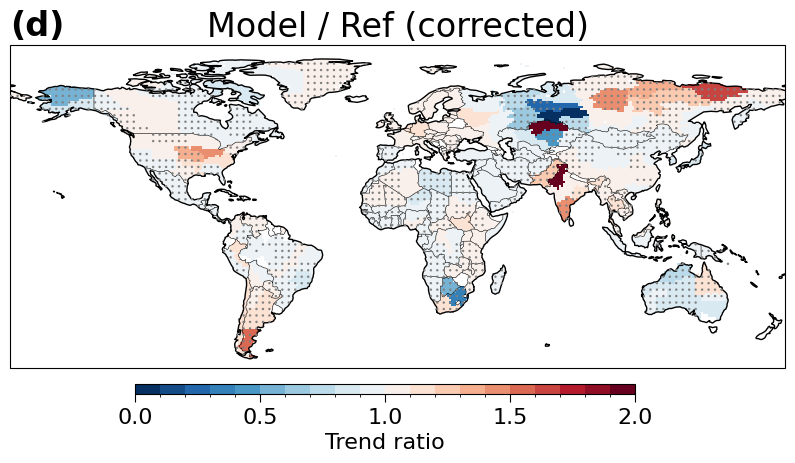

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
from matplotlib.colors import BoundaryNorm
import matplotlib as mpl

# === 1. Load data ===
era5_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")
ens_ds  = xr.open_dataset("IFS_t2m_hottest_month.nc")
region_mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)
fidelity_ds = xr.open_dataset("grid_comparison_fidelity_trend_corrected.nc")

# === 2. Preprocess ===
era5_sel = era5_ds.sel(year=slice(1981, 2024))
era5_years = era5_sel.year.values

ens_t2m = ens_ds["t2m_hottest_month"].transpose("year", "region_id", "number")
ens_years = ens_ds.year.values

# === ✅ NEW STEP: Bias correction based on ERA5 in time segments ===
segments = [(1981,1990), (1991,2000), (2001,2010), (2011,2020), (2021,2024)]

ens_t2m_corrected = ens_t2m.copy()

for start, end in segments:
    era5_seg_mean = era5_sel.sel(year=slice(start,end)).t2m_hottest.mean(dim="year")
    ens_seg_mean = ens_t2m_corrected.sel(year=slice(start,end)).mean(dim="year")
    # compute difference
    delta = era5_seg_mean - ens_seg_mean
    # broadcast delta to ensemble members
    ens_t2m_corrected.loc[dict(year=slice(start,end))] += delta

# === 3. Compute ensemble mean after bias correction ===
ens_mean = ens_t2m_corrected.mean(dim="number")
# ens_mean = ens_t2m.mean(dim="number")
# === 4. Compute trends ===
def compute_trend(y_array, x_years):

    slopes = np.full(y_array.shape[1], np.nan)
    x = x_years - x_years[0]

    for i in range(y_array.shape[1]):
        y = y_array[:, i]
        if np.isnan(y).all():
            continue
        slope, *_ = linregress(x, y)
        slopes[i] = slope * 10

    return slopes


era5_trend = compute_trend(
    era5_sel.t2m_hottest.transpose("year","region_id").values,
    era5_years
)

ens_trend = compute_trend(ens_mean.values, ens_years)

trend_ratio = ens_trend / era5_trend

# === 5. Region → grid mapping ===

region_ids = region_mask_ds["region_id"].values
lat = region_mask_ds["latitude"].values
lon = region_mask_ds["longitude"].values

ratio_map = np.full(region_ids.shape, np.nan)

for rid in np.unique(region_ids):
    if np.isnan(rid):
        continue
    rid = int(rid)
    if rid < len(trend_ratio):
        ratio_map[region_ids == rid] = trend_ratio[rid]

# === 6. Fidelity (REGION LEVEL) ===

fidelity_grid = fidelity_ds["fidelity_score"].values
n_regions = len(trend_ratio)

region_pass = np.zeros(n_regions, dtype=bool)

for rid in range(n_regions):
    mask = region_ids == rid
    if not np.any(mask):
        continue

    pass_fraction = np.nanmean(fidelity_grid[mask] == 3)
    region_pass[rid] = pass_fraction > 0.5

# === 7. Apply fidelity mask (scatter) ===

GREY_VAL = -1e6

masked_ratio = ratio_map.copy()

low_fidelity_mask = np.zeros_like(region_ids, dtype=bool)
for rid in range(n_regions):
    if not region_pass[rid]:
        low_fidelity_mask |= (region_ids == rid)

low_fidelity_mask &= np.isfinite(ratio_map)

SCATTER_STEP = 3
sparse_mask = np.zeros_like(low_fidelity_mask, dtype=bool)
sparse_mask[::SCATTER_STEP, ::SCATTER_STEP] = True

scatter_mask = low_fidelity_mask & sparse_mask

lon2d, lat2d = np.meshgrid(lon, lat)

LOWER_BOUND = 0
masked_ratio[(masked_ratio < LOWER_BOUND)] = LOWER_BOUND

# === 8. Colormap ===
# === 8. Colormap（蓝→红连续，不要白色/银色） ===

STEP = 0.1
MAX_VAL = 2.0
LOWER_BOUND = 0

bounds_real = np.arange(LOWER_BOUND, MAX_VAL + STEP, STEP)

cmap = plt.get_cmap("RdBu_r")  # 蓝→红连续
norm = BoundaryNorm(bounds_real, ncolors=cmap.N, clip=True)

# === 9. Plot ===

fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

pcm = ax.pcolormesh(
    lon,
    lat,
    masked_ratio,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.scatter(
    lon2d[scatter_mask],
    lat2d[scatter_mask],
    s=3,
    color="grey",
    marker="o",
    edgecolors="none",
    transform=ccrs.PlateCarree(),
    zorder=5
)
ax.text(
    0.0,
    1.03,
    '(d)',
    transform=ax.transAxes,
    fontsize=24,
    ha="left",
    fontweight='bold'
)

ax.set_title("Model / Ref (corrected)", fontsize=24)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_extent([-180, 180, -60, 90])

# === 10. Colorbar ===


sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.25, 0.12, 0.5, 0.02])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='horizontal',
    ticks=np.arange(LOWER_BOUND, MAX_VAL + 0.01, 0.5)
)

cbar.set_label("Trend ratio", fontsize=16)
cbar.ax.tick_params(labelsize=16, length=6)

# === 11. Save ===

plt.savefig(
    "ensemble_vs_era5_trend_ratio_corrected.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
from PIL import Image

# =====================================
# 1. 读取四张图
# =====================================
img1 = Image.open("IFS_Statistics_Fidelity_DetailMap.png")
img2 = Image.open("ensemble_mean_trend.png")
img3 = Image.open("ensemble_vs_era5_trend_ratio.png")
img4 = Image.open("ensemble_vs_era5_trend_ratio_corrected.png")

# =====================================
# 2. 获取单张图尺寸
# =====================================
width, height = img1.size

# =====================================
# 3. 设置行间距
# =====================================
vertical_gap = 100   # 像素，可调整

# =====================================
# 4. 创建新画布
# =====================================
new_img = Image.new(
    "RGB",
    (width * 2, height * 2 + vertical_gap),
    (255, 255, 255)
)

# =====================================
# 5. 放置四张图
# =====================================
new_img.paste(img1, (0, 0))                       # 左上
new_img.paste(img2, (width, 0))                   # 右上
new_img.paste(img3, (0, height + vertical_gap))   # 左下
new_img.paste(img4, (width, height + vertical_gap)) # 右下

# =====================================
# 6. 保存
# =====================================
new_img.save("FigS2_fidelity_after_corrected.png", dpi=(400,400))
new_img.show()

FileNotFoundError: [Errno 2] No such file or directory: 'IFS_Statistics_Fidelity_DetailMap.png'

In [8]:
import fitz  # PyMuPDF

# =====================================
# 1. 读取 PDF
# =====================================
pdf1 = fitz.open("IFS_Statistics_Fidelity_DetailMap.pdf")
pdf2 = fitz.open("ensemble_mean_trend.pdf")
pdf3 = fitz.open("ensemble_vs_era5_trend_ratio.pdf")
pdf4 = fitz.open("ensemble_vs_era5_trend_ratio_corrected.pdf")

# =====================================
# 2. 取第一页（假设每个PDF只有1页）
# =====================================
page1 = pdf1[0]
page2 = pdf2[0]
page3 = pdf3[0]
page4 = pdf4[0]

# =====================================
# 3. 获取尺寸
# =====================================
rect = page1.rect
w, h = rect.width, rect.height

vertical_gap = 40   # 单位：points（不是像素！）

# =====================================
# 4. 创建新PDF
# =====================================
out_pdf = fitz.open()

# 画布大小：2×2 + gap
new_width = w * 2
new_height = h * 2 + vertical_gap

new_page = out_pdf.new_page(width=new_width, height=new_height)

# =====================================
# 5. 定义放置位置
# =====================================
pos = {
    "tl": fitz.Rect(0, 0, w, h),  # 左上
    "tr": fitz.Rect(w, 0, 2*w, h),  # 右上
    "bl": fitz.Rect(0, h + vertical_gap, w, 2*h + vertical_gap),  # 左下
    "br": fitz.Rect(w, h + vertical_gap, 2*w, 2*h + vertical_gap)  # 右下
}

# =====================================
# 6. 插入矢量页面
# =====================================
new_page.show_pdf_page(pos["tl"], pdf1, 0)
new_page.show_pdf_page(pos["tr"], pdf2, 0)
new_page.show_pdf_page(pos["bl"], pdf3, 0)
new_page.show_pdf_page(pos["br"], pdf4, 0)

# =====================================
# 7. 保存
# =====================================
out_pdf.save("FigS2_fidelity_after_corrected.pdf")
out_pdf.close()

print("Done: vector figure saved.")

Done: vector figure saved.
